In [2]:
import torch
import numpy as np
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt

import torchvision
import torch.nn as nn
from torch import flatten
from torch.nn.functional import kl_div, log_softmax
from torch.utils.data import Dataset
from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor, Pad, Resize
from torchvision.io import decode_image
from torchinfo import summary as model_summary
from torchvision.models.segmentation import lraspp_mobilenet_v3_large
from torchvision.models.segmentation.lraspp import LRASPPHead

gpu = torch.device('cuda:0')

def n_slice(lists, n):
    if lists == []:
        return []
    return [lists[:n]] + n_slice(lists[n:], n)



In [31]:
class SigmoidWrapper(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        out = self.base_model(x)
        out["out"] = torch.sigmoid(out["out"])
        return out

In [32]:
def OneOutLRASPP():
    model = lraspp_mobilenet_v3_large(num_classes=1)

    old_in = model.backbone["0"][0]
    old_batch_norm1 = model.backbone["0"][1]
    old_conv2 = model.backbone["1"].block[0][0]
    old_bn2 = model.backbone["1"].block[0][1]
    old_conv3 = model.backbone["1"].block[1][0]
    old_bn3 = model.backbone["1"].block[1][1]
    old_conv4 = model.backbone["2"].block[0][0]

    new_in = nn.Conv2d(in_channels=6, out_channels=32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    batch_norm1 = nn.BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    conv2 = nn.Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
    bn2 = nn.BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    conv3 = nn.Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    bn3 = nn.BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
    conv4 = nn.Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)

    with torch.no_grad():
        new_in.weight[16:, 3:, :, :] = old_in.weight
        new_in.weight[:16, :3, :, :] = old_in.weight
        batch_norm1.weight = nn.parameter.Parameter( torch.cat((old_batch_norm1.weight, old_batch_norm1.weight)) )
        conv2.weight[16: , :, :, :] = old_conv2.weight
        conv2.weight[:16 , :, :, :] = old_conv2.weight
        bn2.weight = nn.parameter.Parameter( torch.cat((old_bn2.weight, old_bn2.weight)) )
        conv3.weight[16: , 16:, :, :] = old_conv3.weight
        conv3.weight[:16 , :16, :, :] = old_conv3.weight
        bn3.weight = nn.parameter.Parameter( torch.cat((old_bn3.weight, old_bn3.weight)) )
        conv4.weight[: , 16:, :, :] = old_conv4.weight
        conv4.weight[: , :16, :, :] = old_conv4.weight
    
    model.backbone["0"][0] = new_in
    model.backbone["0"][1] = batch_norm1
    model.backbone["1"].block[0][0] = conv2
    model.backbone["1"].block[0][1] = bn2
    model.backbone["1"].block[1][0] = conv3
    model.backbone["1"].block[1][1] = bn3
    model.backbone["2"].block[0][0] = conv4


    #model.classifier = LRASPPHead(low_channels=128, high_channels=960, num_classes=1, inter_channels=256)

    return SigmoidWrapper(model)

In [4]:
model = OneOutLRASPP()

In [5]:
sum(p.numel() for p in model.parameters())

3221466

In [6]:
def pad_to_n(img, n=500):
    down = n - img.shape[1]
    right = n - img.shape[2]
    pad = Pad((0,0,right,down))
    return pad(img)

In [7]:
def pad_to_640(img):
    return pad_to_n(img, 640)

In [8]:
def normalize_mask(t):
    return torch.div(t, 255)

In [9]:
LRASPP_preprocess = torchvision.transforms.Compose([
    pad_to_640,
    Resize([520,520]),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [10]:
LRASPP_target_preprocess = torchvision.transforms.Compose([
    pad_to_640,
    Resize([520,520]),
    normalize_mask,
])

In [11]:
to_logspace = lambda x: log_softmax(flatten(x, 2), 2)

In [23]:
def loss_fn(x, y):
    x = to_logspace(x)
    y = to_logspace(y)
    return sum([kl_div(input=x[i], target=y[i],log_target=True, reduction="sum") for i in range(len(x))])

In [13]:
class OPADistDataset(Dataset):
    def __init__(self, label_dir, img_dir, obj_dir, mask_dir, transform=None, target_transform=None):
        with open(label_dir, "r") as f:
            self.bbox_label = f.readlines()
        self.img_dir = img_dir
        self.obj_dir = obj_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.bbox_label)

    def __getitem__(self, idx):
        label_line = self.bbox_label[idx].split(",")        
        cat = label_line[2]
        img_id = label_line[1]
        obj_id = label_line[0]
        img_name = img_id + ".jpg"
        obj_name = obj_id + ".jpg"
        comp_name = obj_id + "c" + img_id

        img_path = os.path.join(self.img_dir, cat, img_name)
        obj_path = os.path.join(self.obj_dir, cat, obj_name)    
        mask_path = os.path.join(self.mask_dir, cat, comp_name + ".jpg")
        image = decode_image(img_path).type(torch.float32)
        obj = decode_image(obj_path).type(torch.float32)
        mask = decode_image(mask_path).type(torch.uint8)

        if self.transform:
            image = self.transform(image)
            obj = self.transform(image)
        if self.target_transform:
            label = self.target_transform(mask)
        example = torch.cat((image,obj),0)
        
        return example.to(gpu), label.to(gpu), comp_name

In [14]:
test_label_dir = "new_alt_test_label.csv"
train_label_dir = "new_alt_train_label.csv"
img_dir = "background/"
obj_dir = "foreground/"
mask_dir = "weighted/"
transform = LRASPP_preprocess
target_transform = LRASPP_target_preprocess

In [15]:
test_dataset = OPADistDataset(test_label_dir, img_dir, obj_dir, mask_dir, transform, target_transform)
train_dataset = OPADistDataset(train_label_dir, img_dir, obj_dir, mask_dir, transform, target_transform)

In [16]:
test_dataloader = DataLoader(test_dataset, batch_size=32)
train_dataloader = DataLoader(train_dataset, batch_size=32)

In [17]:
!ls ../../../saved_model/

12weight.pt  82weight.pt	    OPA_resnet512_xyxy.pt
22weight.pt  92weight.pt	    resnet_50_noobj_altlabel.pt
32weight.pt  doubleres_altlabel.pt  resnet_50_noobj_weights.pt
42weight.pt  doubleres.pt	    resnet_50_obj_altlabel.pt
52weight.pt  lraspp_failed.pt	    resnet_50_obj.pt
62weight.pt  naive_altlabel.pt	    resnet_OPA_xywh.pt
72weight.pt  naive.pt


In [18]:
model.load_state_dict(torch.load("../../../saved_model/lraspp_failed.pt", weights_only=True))
model.eval()

LRASPP(
  (backbone): IntermediateLayerGetter(
    (0): Conv2dNormActivation(
      (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1

In [19]:
model.to(gpu)

LRASPP(
  (backbone): IntermediateLayerGetter(
    (0): Conv2dNormActivation(
      (0): Conv2d(6, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(32, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(1

In [20]:
result_dict = {}

In [21]:
my_y = None
my_p = None
def test_loop(dataloader, model, loss_fn,result_dict, t=None):
    global my_y, my_p
    model.eval()
    batch_num = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y,_ in dataloader:
            pred = model(X)
            #print(pred["out"].shape)
            #print(torch.sum(nn.functional.softmax(pred["out"], 2)))
            #print(nn.functional.softmax(y, 2))
            test_loss += loss_fn(pred["out"], y).item() 
            my_y = y
            my_p = pred["out"]
            break
    #print(f"epoch: {t + 1}, avg test loss: {test_loss/batch_num}")
    if t is not None:
        result_dict[t]["test"] = test_loss # edit dict because we run test AFTER train in each epoch

In [26]:
test_loop(train_dataloader,model,loss_fn,result_dict)

In [27]:
my_y.shape

torch.Size([32, 1, 520, 520])

In [40]:
import matplotlib.pyplot as plt

In [28]:
torch.unique(flatten(my_y[1][0]))

tensor([0.0000, 0.0039, 0.0078, 0.0118, 0.0157, 0.0196, 0.0235, 0.0275, 0.0314,
        0.0353, 0.0392, 0.0431, 0.0471, 0.0510, 0.0549, 0.0588, 0.0627, 0.0667,
        0.0706, 0.0824, 0.0863, 0.0902, 0.0941, 0.0980, 0.1020, 0.1059, 0.1098,
        0.1137, 0.1176, 0.1216, 0.1255, 0.1294, 0.1412, 0.1451, 0.1490, 0.1529,
        0.1569, 0.1608, 0.1647, 0.1686, 0.1725, 0.1765, 0.1804, 0.1843, 0.1882,
        0.1922, 0.1961, 0.2000, 0.2039, 0.2078, 0.2118, 0.2157, 0.2196, 0.2235,
        0.2275, 0.2314, 0.2353, 0.2392, 0.2431, 0.2471, 0.2510, 0.2549, 0.2588,
        0.2667, 0.2706, 0.2745, 0.2784, 0.2824, 0.2863, 0.2902, 0.2941, 0.2980,
        0.3020, 0.3059, 0.3137, 0.3176, 0.3216, 0.3255, 0.3294, 0.3333, 0.3373,
        0.3412, 0.3451, 0.3490, 0.3529, 0.3569, 0.3608, 0.3647, 0.3686, 0.3725,
        0.3765, 0.3804, 0.3843, 0.3882, 0.3922, 0.3961, 0.4000, 0.4039, 0.4078,
        0.4118, 0.4157, 0.4196, 0.4235, 0.4275, 0.4353, 0.4392, 0.4431, 0.4471,
        0.4510, 0.4549, 0.4588, 0.4627, 

In [30]:
torch.unique(flatten(my_p[1][0]))

tensor([5.1230, 5.1232, 5.1234,  ..., 6.0303, 6.0308, 6.0332], device='cuda:0')

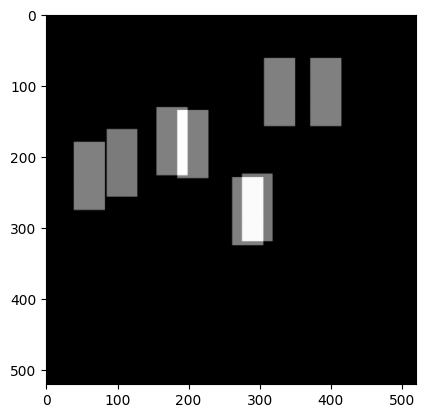

In [52]:
plt.imshow(my_y[1][0].cpu(), cmap="grey")

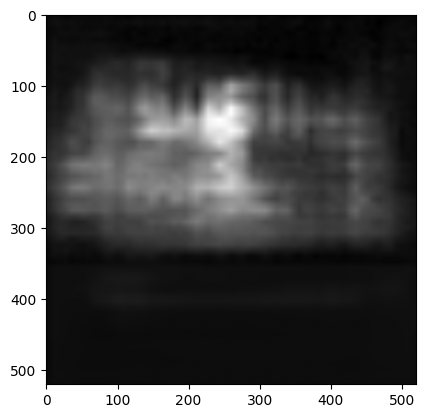

In [53]:
plt.imshow(my_p[1][0].cpu(), cmap="grey")

In [54]:
my_p[1][0]

tensor([[5.2797, 5.2797, 5.2797,  ..., 5.2769, 5.2769, 5.2769],
        [5.2797, 5.2797, 5.2797,  ..., 5.2769, 5.2769, 5.2769],
        [5.2797, 5.2797, 5.2797,  ..., 5.2769, 5.2769, 5.2769],
        ...,
        [5.2857, 5.2857, 5.2857,  ..., 5.2915, 5.2915, 5.2915],
        [5.2857, 5.2857, 5.2857,  ..., 5.2915, 5.2915, 5.2915],
        [5.2857, 5.2857, 5.2857,  ..., 5.2915, 5.2915, 5.2915]],
       device='cuda:0')

In [21]:
a = torch.randn((3, 1, 2, 2))

In [37]:
a

tensor([[[[ 0.7330,  0.2577],
          [-1.0110,  0.8376]]],


        [[[ 0.0443,  1.1779],
          [-0.2721,  0.0251]]],


        [[[-0.9290,  0.4493],
          [ 1.8812,  0.3679]]]])

In [39]:
f = flatten(a, 2)

In [40]:
f

tensor([[[ 0.7330,  0.2577, -1.0110,  0.8376]],

        [[ 0.0443,  1.1779, -0.2721,  0.0251]],

        [[-0.9290,  0.4493,  1.8812,  0.3679]]])

In [42]:
f.shape

torch.Size([3, 1, 4])

In [50]:
flatten(nn.functional.softmax(f, 2),1)

tensor([[0.3440, 0.2139, 0.0601, 0.3820],
        [0.1719, 0.5341, 0.1253, 0.1687],
        [0.0396, 0.1572, 0.6582, 0.1449]])

In [ ]:
nn.functional.softmax()

In [15]:
def train_loop(dataloader, model, loss_fn, optimizer, result_dict, t=None):
    batch_num = len(dataloader)
    model.train()
    total_loss = 0
    for batch, (X, y, _) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)
        total_loss += loss.item()

        # Backpropagation
        #loss.requires_grad = True
        #loss.to(gpu)
        #print(loss)
        #print()
        loss.backward()
        """
        for each_loss in loss:
            each_loss.backward(retain_graph=True)"""
        optimizer.step()
        optimizer.zero_grad()
    print(f"epoch: {t + 1}, avg train loss: {total_loss/batch_num}")
    if t is not None:
        result_dict[t] = {"train": total_loss/batch_num} # create dict because we run train BEFORE test in each epoch

In [17]:
import json

In [40]:
result_dict = {}
lr = 0.001
optim = torch.optim.Adam(model.parameters(), lr=lr)

for t in range(10):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optim, result_dict, t)
    test_loop(test_dataloader, model, loss_fn, result_dict, t)
    print("-------------------------------\n")
print(("*"*100)+"\nDone!")

with open("output/trainingresult.json", "w") as f:
    json.dump(result_dict, f)
print("Training result saved to output/trainingresult.json")

Epoch 1
-------------------------------
epoch: 1, avg train loss: 0.028482012229191292
1.0556687135249376
epoch: 1, avg test loss: 0.034053829468546376
-------------------------------

Epoch 2
-------------------------------
epoch: 2, avg train loss: 0.02203884502822483
0.9240362960845232
epoch: 2, avg test loss: 0.029807622454339457
-------------------------------

Epoch 3
-------------------------------
epoch: 3, avg train loss: 0.0205893934779876
0.8858722895383835
epoch: 3, avg test loss: 0.028576525468980114
-------------------------------

Epoch 4
-------------------------------
epoch: 4, avg train loss: 0.019710025443015873
0.9277340359985828
epoch: 4, avg test loss: 0.02992690438705106
-------------------------------

Epoch 5
-------------------------------
epoch: 5, avg train loss: 0.01916047812917748
0.9804723113775253
epoch: 5, avg test loss: 0.031628139076694366
-------------------------------

Epoch 6
-------------------------------
epoch: 6, avg train loss: 0.018871095177

FileNotFoundError: [Errno 2] No such file or directory: 'output/trainingresult.json'

In [18]:
def test_loop(dataloader, model, loss_fn,result_dict, t=None):
    model.eval()
    batch_num = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y,_ in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()    
    print(f"epoch: {t + 1}, avg test loss: {test_loss/batch_num}")
    if t is not None:
        result_dict[t]["test"] = test_loss # edit dict because we run test AFTER train in each epoch

In [44]:
def save_dist_eval(dataset, model, loss_fn, out_dir="output/"):
    # Do prediction one by one so we can save result
    model.eval()
    total_loss = 0    
    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y, n in dataset:
            pred = model(X)["out"]
            for i, x in enumerate(pred):
                fn = os.path.join(out_dir, n[i] + ".png")
                x = torch.clamp(x[0], min=0,max=1)
                img = (x * 255).cpu().numpy().astype('uint8')
                cv2.imwrite(fn, img)

In [45]:
save_dist_eval(test_dataloader,model,loss_fn)

In [24]:
pred[1]

NameError: name 'pred' is not defined